# Probability that two districts produce the same vote counts

**Purely a math exercise** — not an attempt to prove or disprove anything. We just compute, under an explicit probabilistic model, the chance that two independent districts land on the *same* counts for the top two candidates.

## Data
| | total | cand 1 | cand 2 | other / ineligible |
|---|---|---|---|---|
| Songdo1 | 4548 | 3030 | 1440 | 78 |
| Songdo2 | 4540 | 3030 | 1440 | 70 |

So the two districts agree exactly on cand 1 (3030) and cand 2 (1440); only the totals differ by 8 votes (the "other" bucket: 78 vs 70).

## Model
Per district $i$: a probability vector $p^{(i)} \sim \text{Dirichlet}(\alpha)$ over the 3 categories (cand1, cand2, other), then counts $\sim \text{Multinomial}(N_i, p^{(i)})$. Marginalizing $p$, the counts follow a **Dirichlet–Multinomial** $(N_i, \alpha)$, and the two districts are independent.

## The real blocker: $\alpha$ (this is the whole ballgame)
Write $\alpha = \kappa\, u$ with $\sum_k u_k = 1$.
- $u$ = **mean direction**. Easy: each district gets its *own* observed shares — $u^{(1)}=(3030,1440,78)/4548$ and $u^{(2)}=(3030,1440,70)/4540$ — i.e. **two separate Dirichlets, one per district** (as you intended). This centers each district's model exactly on its own data, so the expected cand1/cand2 counts are exactly 3030/1440 in *both*.
- $\kappa$ = **concentration**. This is *not* pinned down by matching the mean, and it is what actually determines the answer.

Two key facts that resolve your "how do I pick $\alpha$" question:

1. **The collision probability is monotincreasing in $\kappa$, and its supremum is $\kappa\to\infty$, which is just plain Multinomial$(N,u)$.** Dirichlet over-dispersion only *spreads counts out more*, which makes a collision *less* likely. So the **most generous / best-case** number for "it's just a coincidence" is the multinomial with $p=$ observed shares. The Dirichlet can never beat it.

2. **"Fit $\kappa$ on the current data" is circular here.** MLE of the concentration from two nearly-identical observations pushes $\kappa\to\infty$ (the model "sees" no district-to-district variation), which just recovers the multinomial again. To get a *realistic* finite $\kappa$ you must estimate the genuine across-district spread of vote shares from **past / other-district data** — and that always gives a far smaller collision probability than the multinomial bound.

So we report a **range**:
- **Upper bound (best case):** Multinomial, $p=$ observed shares.
- **Realistic:** Dirichlet–Multinomial with $\kappa$ from real across-district variation.

We also separate two distinct questions, because they differ by orders of magnitude:
- **(A) Collision:** the two districts match each other on (cand1, cand2) at *any* common value.
- **(B) Exact value:** both hit the *specific* (3030, 1440).

In [1]:
import numpy as np
from scipy.special import gammaln
from scipy.stats import binom

# --- Data -------------------------------------------------------------------
N1, N2 = 4548, 4540          # district totals
c1, c2 = 3030, 1440          # the two matched counts
other1, other2 = N1 - c1 - c2, N2 - c1 - c2
print("other:", other1, other2)

# Two separate Dirichlets: each district's mean = its OWN observed shares.
u1 = np.array([c1, c2, other1]) / N1
u2 = np.array([c1, c2, other2]) / N2
print("u1 (Songdo1):", np.round(u1, 5), " sum =", u1.sum())
print("u2 (Songdo2):", np.round(u2, 5), " sum =", u2.sum())
print("expected cand1/cand2 counts:",
      (N1 * u1[0], N1 * u1[1]), (N2 * u2[0], N2 * u2[1]))  # exactly 3030 / 1440 each

other: 78 70
u1 (Songdo1): [0.66623 0.31662 0.01715]  sum = 1.0
u2 (Songdo2): [0.6674  0.31718 0.01542]  sum = 1.0
expected cand1/cand2 counts: (np.float64(3030.0), np.float64(1440.0)) (np.float64(3030.0), np.float64(1440.0))


## Exact collision via a sequential factorization

We need the joint pmf of $(n_1,n_2)$ for each district and then
$$P_\text{collision} = \sum_{a,b} P_1(n_1=a,n_2=b)\,P_2(n_1=a,n_2=b).$$

Both models factor nicely, which lets us compute this **exactly** (no Monte Carlo) and cheaply:

- **Multinomial:** $n_1\sim\text{Binom}(N,p_1)$, and $n_2\mid n_1{=}a \sim \text{Binom}(N-a,\;p_2/(1-p_1))$.
- **Dirichlet–Multinomial:** $n_1\sim\text{BetaBinom}(N,\alpha_1,\alpha_2{+}\alpha_3)$, and $n_2\mid n_1{=}a \sim \text{BetaBinom}(N-a,\alpha_2,\alpha_3)$.

So $P_\text{collision} = \sum_a w(a)\,\big[\sum_b P_1(b\mid a)P_2(b\mid a)\big]$ where $w(a)=P_1(n_1{=}a)P_2(n_1{=}a)$. We only iterate over the $a$ that carry non-negligible mass.

In [2]:
def betabinom_logpmf(k, n, a, b):
    """log P(X=k), X ~ Beta-Binomial(n, a, b). Vectorized over integer array k."""
    return (gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1)
            + gammaln(k + a) + gammaln(n - k + b) - gammaln(n + a + b)
            - (gammaln(a) + gammaln(b) - gammaln(a + b)))


def collision_dirichlet_multinomial(N1, N2, alphaA, alphaB):
    """Two independent districts with their OWN Dirichlet params alphaA, alphaB."""
    a1A, a2A, a3A = alphaA
    a1B, a2B, a3B = alphaB
    amax = min(N1, N2)
    a = np.arange(amax + 1)
    logm1 = betabinom_logpmf(a, N1, a1A, a2A + a3A)   # district A, cand1 marginal
    logm2 = betabinom_logpmf(a, N2, a1B, a2B + a3B)   # district B, cand1 marginal
    lw = logm1 + logm2
    keep = np.where(lw > lw.max() + np.log(1e-15))[0]
    total = 0.0
    for ai in keep:
        b = np.arange(amax - ai + 1)
        lb1 = betabinom_logpmf(b, N1 - ai, a2A, a3A)  # district A, cand2 | cand1=ai
        lb2 = betabinom_logpmf(b, N2 - ai, a2B, a3B)  # district B, cand2 | cand1=ai
        total += np.exp(logm1[ai] + logm2[ai]) * np.sum(np.exp(lb1 + lb2))
    return total


def collision_multinomial(N1, N2, pA, pB):
    """Two independent districts with their OWN multinomial probs pA, pB."""
    pcA = pA[1] / (1 - pA[0])        # cand2 prob conditional on non-cand1
    pcB = pB[1] / (1 - pB[0])
    amax = min(N1, N2)
    a = np.arange(amax + 1)
    w = binom.pmf(a, N1, pA[0]) * binom.pmf(a, N2, pB[0])
    keep = np.where(w > w.max() * 1e-15)[0]
    total = 0.0
    for ai in keep:
        b = np.arange(amax - ai + 1)
        c_1 = binom.pmf(b, N1 - ai, pcA)
        c_2 = binom.pmf(b, N2 - ai, pcB)
        total += w[ai] * np.sum(c_1 * c_2)
    return total


def joint_logpmf_dm(n1, n2, N, alpha):
    """log P(cand1=n1, cand2=n2) for one district, Dirichlet-Multinomial(N, alpha)."""
    a1, a2, a3 = alpha
    n3 = N - n1 - n2
    A = a1 + a2 + a3
    return (gammaln(N + 1) - gammaln(n1 + 1) - gammaln(n2 + 1) - gammaln(n3 + 1)
            + gammaln(n1 + a1) + gammaln(n2 + a2) + gammaln(n3 + a3) - gammaln(N + A)
            + gammaln(A) - gammaln(a1) - gammaln(a2) - gammaln(a3))


def joint_logpmf_multinomial(n1, n2, N, p):
    p1, p2, p3 = p
    n3 = N - n1 - n2
    return (gammaln(N + 1) - gammaln(n1 + 1) - gammaln(n2 + 1) - gammaln(n3 + 1)
            + n1 * np.log(p1) + n2 * np.log(p2) + n3 * np.log(p3))

In [3]:
# ============================================================================
# UPPER BOUND (best case for "pure coincidence"): Multinomial, p = observed shares
# ============================================================================
p_collision_mn = collision_multinomial(N1, N2, u1, u2)

# (B) probability both districts hit the SPECIFIC (3030, 1440)
log_specific = (joint_logpmf_multinomial(c1, c2, N1, u1)
                + joint_logpmf_multinomial(c1, c2, N2, u2))
p_specific_mn = np.exp(log_specific)

print("=== Multinomial (best case, kappa -> inf) ===")
print(f"(A) collision  P(match on cand1 AND cand2) = {p_collision_mn:.3e}  ~ 1 in {1/p_collision_mn:,.0f}")
print(f"(B) exact      P(both = (3030,1440))        = {p_specific_mn:.3e}  ~ 1 in {1/p_specific_mn:,.0f}")

=== Multinomial (best case, kappa -> inf) ===
(A) collision  P(match on cand1 AND cand2) = 2.988e-04  ~ 1 in 3,347
(B) exact      P(both = (3030,1440))        = 3.562e-07  ~ 1 in 2,807,775


## Concentration sweep: how $\kappa$ moves the answer

We hold $u$ fixed at the observed shares and sweep $\kappa$ in $\alpha=\kappa u$. As $\kappa\to\infty$ the Dirichlet–Multinomial collision probability should climb up to the multinomial value computed above — confirming that the multinomial really is the ceiling.

kappa =         30   P(collision) = 4.904e-06   ~ 1 in 203,931
kappa =        100   P(collision) = 8.410e-06   ~ 1 in 118,907
kappa =        300   P(collision) = 1.999e-05   ~ 1 in 50,017
kappa =       1000   P(collision) = 5.507e-05   ~ 1 in 18,159
kappa =       3000   P(collision) = 1.196e-04   ~ 1 in 8,359
kappa =      10000   P(collision) = 2.058e-04   ~ 1 in 4,859
kappa =      30000   P(collision) = 2.596e-04   ~ 1 in 3,852
kappa =     100000   P(collision) = 2.858e-04   ~ 1 in 3,499
kappa =    1000000   P(collision) = 2.974e-04   ~ 1 in 3,362

multinomial limit                P(collision) = 2.988e-04


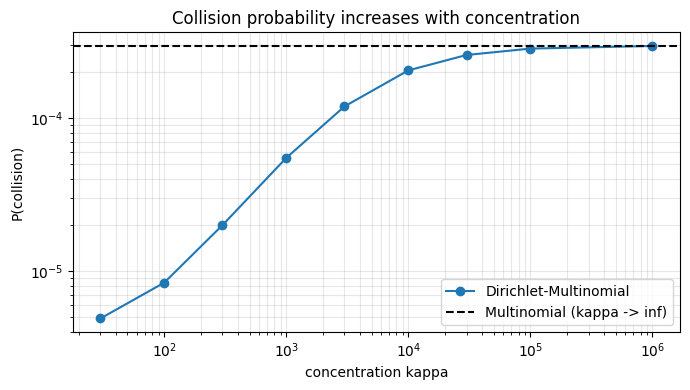

In [4]:
import matplotlib.pyplot as plt

kappas = np.array([30, 100, 300, 1e3, 3e3, 1e4, 3e4, 1e5, 1e6])
coll = np.array([collision_dirichlet_multinomial(N1, N2, k * u1, k * u2) for k in kappas])

for k, c in zip(kappas, coll):
    print(f"kappa = {k:>10.0f}   P(collision) = {c:.3e}   ~ 1 in {1/c:,.0f}")
print(f"\nmultinomial limit                P(collision) = {p_collision_mn:.3e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(kappas, coll, "o-", label="Dirichlet-Multinomial")
ax.axhline(p_collision_mn, color="k", ls="--", label="Multinomial (kappa -> inf)")
ax.set_xlabel("concentration kappa")
ax.set_ylabel("P(collision)")
ax.set_title("Collision probability increases with concentration")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## Getting a *realistic* $\kappa$ from past / across-district data

This is the answer to "based on past voting pattern". The Dirichlet mean/variance for component $k$ is
$$\mathbb{E}[p_k]=u_k,\qquad \operatorname{Var}(p_k)=\frac{u_k(1-u_k)}{\kappa+1}.$$
So if you measure, across many real districts, the standard deviation $s_k$ of candidate $k$'s **vote share**, a method-of-moments estimate is
$$\kappa \approx \frac{u_k(1-u_k)}{s_k^2}-1.$$
(With several candidates, average the per-candidate estimates, or fit the Dirichlet–Multinomial by MLE on the full multi-district count table — `betabinom_logpmf` already gives you the likelihood pieces.)

Real district-level vote shares typically vary by **several percentage points**, which implies a *small* $\kappa$ (tens to low hundreds) and hence a collision probability far below the multinomial ceiling. Below we turn an assumed across-district share-SD into $\kappa$ so you can plug in the real number once you have it.

In [5]:
def kappa_from_share_sd(u_k, s_k):
    """Method-of-moments concentration from one candidate's across-district share SD."""
    return u_k * (1 - u_k) / s_k**2 - 1

# Illustrative across-district SDs of vote share (REPLACE with real values).
for s in [0.01, 0.02, 0.03, 0.05]:
    k_hat = kappa_from_share_sd(u1[0], s)        # use cand 1 as the anchor
    c = collision_dirichlet_multinomial(N1, N2, k_hat * u1, k_hat * u2)
    print(f"share SD = {s:.0%}  ->  kappa ~= {k_hat:7.1f}  ->  P(collision) = {c:.3e}  (1 in {1/c:,.0f})")

share SD = 1%  ->  kappa ~=  2222.7  ->  P(collision) = 9.906e-05  (1 in 10,095)
share SD = 2%  ->  kappa ~=   554.9  ->  P(collision) = 3.385e-05  (1 in 29,544)


share SD = 3%  ->  kappa ~=   246.1  ->  P(collision) = 1.690e-05  (1 in 59,185)


share SD = 5%  ->  kappa ~=    87.9  ->  P(collision) = 7.745e-06  (1 in 129,109)


In [6]:
# --- Monte Carlo sanity check on the exact multinomial collision number -----
rng = np.random.default_rng(0)
M = 5_000_000
d1 = rng.multinomial(N1, u1, size=M)[:, :2]
d2 = rng.multinomial(N2, u2, size=M)[:, :2]
hits = np.all(d1 == d2, axis=1).mean()
print(f"Monte Carlo P(collision) = {hits:.3e}   (exact = {p_collision_mn:.3e})")

Monte Carlo P(collision) = 2.996e-04   (exact = 2.988e-04)


In [7]:
import math